In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
mount_path = '/content/drive/'
drive.mount(mount_path)

file_path_listings_cleaned = mount_path + 'My Drive/Colab Notebooks/listings_cleaned.csv'
file_path_reviews = mount_path + 'My Drive/Colab Notebooks/reviews.csv'

Mounted at /content/drive/


In [2]:
# 1) Carregamento e Exploração Inicial dos Dados
print("1) Carregamento e Exploração Inicial dos Dados\n")

# Carregar os datasets
listings_df = pd.read_csv(file_path_listings_cleaned)
reviews_df = pd.read_csv(file_path_reviews)

# Exibir as primeiras linhas
print('Listings DataFrame Head:\n', listings_df.head())
print('\nReviews DataFrame Head:\n', reviews_df.head())

# Unir os DataFrames
merged_df = pd.merge(listings_df, reviews_df, on='id', how='inner')
print('\nMerged DataFrame Head:\n', merged_df.head())

# Salvar o DataFrame mesclado
merged_df.to_csv('airbnb_merged.csv', index=False)

1) Carregamento e Exploração Inicial dos Dados

Listings DataFrame Head:
        id neighbourhood_cleansed        room_type  accommodates  bathrooms  \
0  271975                Vidigal  Entire home/apt             4        1.0   
1  272335             Copacabana  Entire home/apt             4        1.0   
2  272631             Copacabana     Private room             2        1.0   
3  273261                 Leblon  Entire home/apt             6        3.5   
4  273363           Santa Teresa     Private room             1        1.0   

   bedrooms  beds   price  
0       2.0   2.0   236.0  
1       1.0   1.0   723.0  
2       1.0   2.0  1146.0  
3       3.0   3.0  6742.0  
4       1.0   1.0    61.0  

Reviews DataFrame Head:
        id  number_of_reviews  review_scores_rating
0  272335                367                  4.92
1  272631                 32                  5.00
2  273363                  5                  5.00
3  273463                654                  4.83
4  27349

In [3]:
# 2) Limpeza e Tratamento de Dados
print("2) Limpeza e Tratamento de Dados\n")

merged_df = pd.read_csv('airbnb_merged.csv')
print('Valores Ausentes:\n', merged_df.isnull().sum())
print('Tipos de Dados:\n', merged_df.info())

2) Limpeza e Tratamento de Dados

Valores Ausentes:
 id                        0
neighbourhood_cleansed    0
room_type                 0
accommodates              0
bathrooms                 0
bedrooms                  0
beds                      0
price                     0
number_of_reviews         0
review_scores_rating      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32695 entries, 0 to 32694
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      32695 non-null  int64  
 1   neighbourhood_cleansed  32695 non-null  object 
 2   room_type               32695 non-null  object 
 3   accommodates            32695 non-null  int64  
 4   bathrooms               32695 non-null  float64
 5   bedrooms                32695 non-null  float64
 6   beds                    32695 non-null  float64
 7   price                   32695 non-null  float64
 8   number_of_

In [4]:
# 3) Detecção e Tratamento de Outliers
print("3) Limpeza e Tratamento de Dados\n")

# Gerar boxplot do preço
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['price'])
plt.title('Boxplot do Preço da Diária')
plt.ylabel('Preço')
plt.savefig('boxplot_price.png')
plt.close()

# Calcular Q1, Q3 e IQR
Q1 = merged_df['price'].quantile(0.25)
Q3 = merged_df['price'].quantile(0.75)
IQR = Q3 - Q1

# Definir limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remover outliers
df_no_outliers = merged_df[(merged_df['price'] >= lower_bound) & (merged_df['price'] <= upper_bound)]

# Salvar o DataFrame sem outliers
df_no_outliers.to_csv('airbnb_no_outliers.csv', index=False)

print(f'Shape do DataFrame original: {merged_df.shape}')
print(f'Shape do DataFrame sem outliers: {df_no_outliers.shape}')

3) Limpeza e Tratamento de Dados

Shape do DataFrame original: (32695, 10)
Shape do DataFrame sem outliers: (31772, 10)


In [5]:
# 4) Transformação de Dados Categóricos
print("4) Transformação de Dados Categóricos\n")

df_no_outliers = pd.read_csv('airbnb_no_outliers.csv')

# Codificar a coluna 'room_type'
df_no_outliers['room_type_encoded'] = df_no_outliers['room_type'].astype('category').cat.codes

# Salvar o DataFrame transformado
df_no_outliers.to_csv('airbnb_transformed.csv', index=False)

print('DataFrame com room_type_encoded:\n', df_no_outliers.head())

4) Transformação de Dados Categóricos

DataFrame com room_type_encoded:
        id neighbourhood_cleansed        room_type  accommodates  bathrooms  \
0  272335             Copacabana  Entire home/apt             4        1.0   
1  272631             Copacabana     Private room             2        1.0   
2  273363           Santa Teresa     Private room             1        1.0   
3  273463                  Lagoa  Entire home/apt             6        2.0   
4  273496                 Leblon  Entire home/apt             6        2.5   

   bedrooms  beds   price  number_of_reviews  review_scores_rating  \
0       1.0   1.0   723.0                367                  4.92   
1       1.0   2.0  1146.0                 32                  5.00   
2       1.0   1.0    61.0                  5                  5.00   
3       2.0   6.0  1411.0                654                  4.83   
4       2.0   5.0   703.0                 60                  4.80   

   room_type_encoded  
0             

5) Análise Exploratória

Histograma de Preço e Avaliação



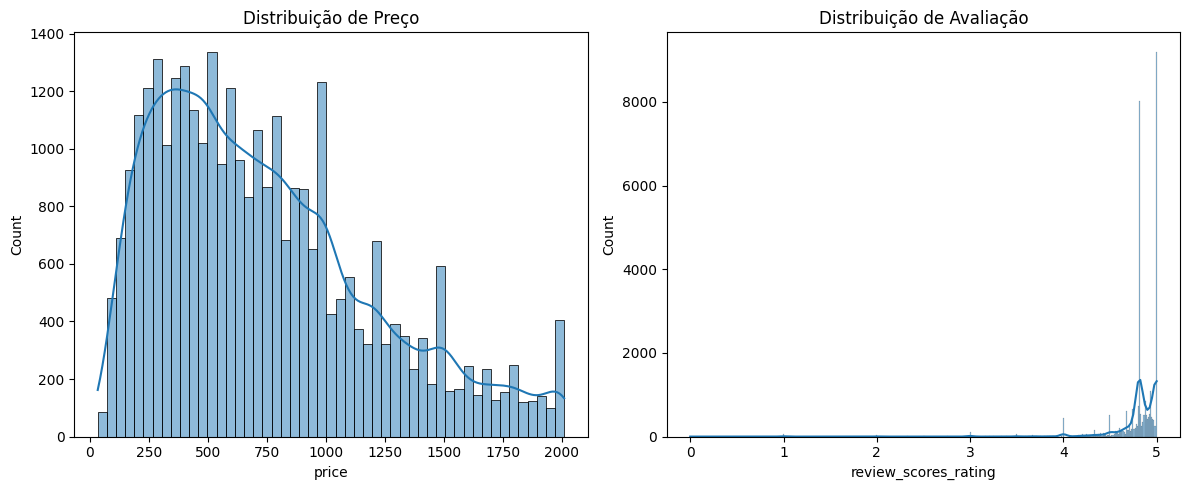



Scatter Plot Preço vs. Avaliação



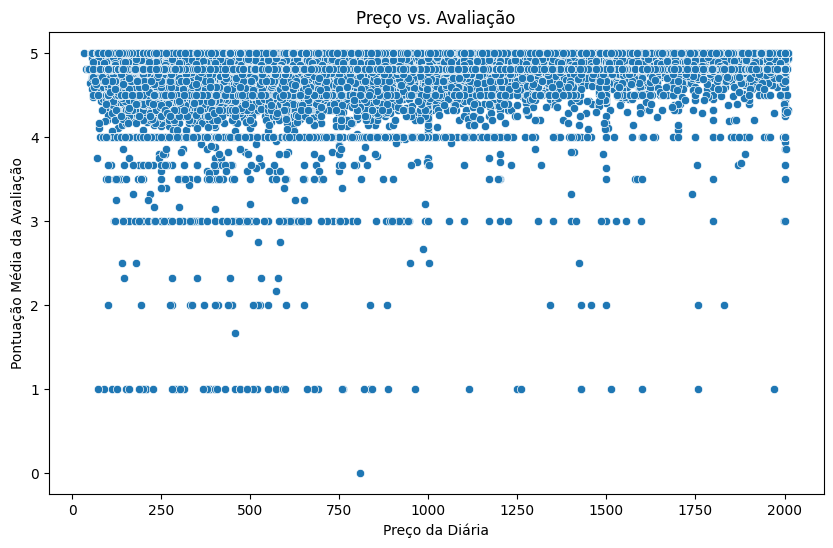



Gráfico de Barras Tipos de Acomodação



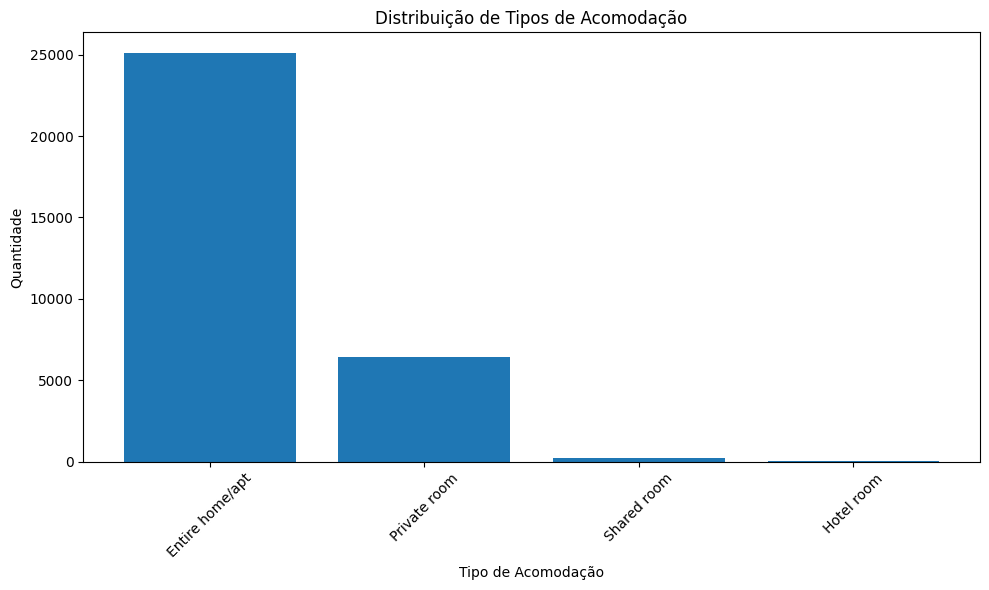




Head do DataFrame Final:
        id neighbourhood_cleansed        room_type  accommodates  bathrooms  \
0  272335             Copacabana  Entire home/apt             4        1.0   
1  272631             Copacabana     Private room             2        1.0   
2  273363           Santa Teresa     Private room             1        1.0   
3  273463                  Lagoa  Entire home/apt             6        2.0   
4  273496                 Leblon  Entire home/apt             6        2.5   

   bedrooms  beds   price  number_of_reviews  review_scores_rating  \
0       1.0   1.0   723.0                367                  4.92   
1       1.0   2.0  1146.0                 32                  5.00   
2       1.0   1.0    61.0                  5                  5.00   
3       2.0   6.0  1411.0                654                  4.83   
4       2.0   5.0   703.0                 60                  4.80   

   room_type_encoded  
0                  0  
1                  2  
2           

In [6]:
# 5) Análise Exploratória
print("5) Análise Exploratória\n")

df = pd.read_csv('airbnb_transformed.csv')

# Histograma de Preço e Avaliação
print('Histograma de Preço e Avaliação\n')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True)
plt.title('Distribuição de Preço')
plt.subplot(1, 2, 2)
sns.histplot(df['review_scores_rating'], kde=True)
plt.title('Distribuição de Avaliação')
plt.tight_layout()
plt.savefig('histograms_price_reviews.png')
# plt.close()
plt.show()
print('\n')

# Scatter Plot Preço vs. Avaliação
print('Scatter Plot Preço vs. Avaliação\n')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='review_scores_rating', data=df)
plt.title('Preço vs. Avaliação')
plt.xlabel('Preço da Diária')
plt.ylabel('Pontuação Média da Avaliação')
plt.savefig('scatterplot_price_reviews.png')
# plt.close()
plt.show()
print('\n')

# Gráfico de Barras Tipos de Acomodação
print('Gráfico de Barras Tipos de Acomodação\n')
plt.figure(figsize=(10, 6))
room_type_counts = df['room_type'].value_counts()
plt.bar(room_type_counts.index, room_type_counts.values)
plt.title('Distribuição de Tipos de Acomodação')
plt.xlabel('Tipo de Acomodação')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('barplot_room_type.png')
# plt.close()
plt.show()
print('\n')

print('\nHead do DataFrame Final:\n', df.head())
print('\nInfo do DataFrame Final:\n')
df.info()
print('\nDescribe do DataFrame Final:\n', df.describe())
print('\nColunas do DataFrame Final:\n', df.columns)